##### **Get 200 transcripts as list of dictionaries**

In [ ]:
import json

transcripts = []

with open("4300_transcripts.json", "r") as f:
    for line in f:
        obj = json.loads(line)
        transcripts.append({
            "url": obj["url"],
            "title": obj["title"],
            "content": obj["content"]
        })

transcripts= transcripts[:200]

In [ ]:
transcripts[0]

{'url': 'https://scrapsfromtheloft.com/comedy/jeff-foxworthy-totally-committed-transcript/',
 'title': 'Jeff Foxworthy: Totally Committed (1998) – Full Transcript',
 'content': 'Ladies and gentlemen, please welcome Jeff Foxworthy!\nThank you. Thank you very much. Nice to be back in Cincinnati! Special city special night special boots I bought new boots for the show. Can you see those? [applause from the audience] Blue stingray boots. Boots that make a statement. And that statement is… you can’t give rednecks money. [laughter] ‘Cause that’s the kind of thing we do with it. Open up a savings account? Hell no! Go buy some blue stingray boots! [laughter] A couple of weeks ago I was playing at a casino in Mississippi—which by the way is the only place in America where you can shoot craps and doves within 10 feet of each other—and I was standing off the side of the stage in one of the states handsome man with in boots made out of I said their stingray he said or they waterproof? now he Dre o

##### **Chart Creation**

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
all_words = []

for t in transcripts:
    text = t["content"].lower()
    words = re.findall(r"\b[a-z']+\b", text)
    all_words.extend(words)

word_counts = Counter(all_words)

###### **Top 15 Most Common Words**

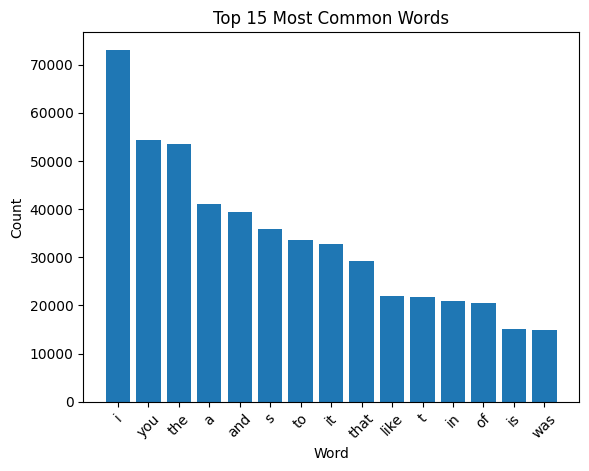

In [ ]:
top15 = word_counts.most_common(15)

words = [w for w, c in top15]
counts = [c for w, c in top15]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Most Common Words")
plt.ylabel("Count")
plt.xlabel("Word")
plt.show()

###### **Top 15 Most Common Words After Stopwords are Filtered**

In [ ]:
import re

clean_words = []

for t in transcripts:
    text = t["content"].lower()

    # remove stage directions like [laughter], [applause], [cheers]
    text = re.sub(r"\[.*?\]", " ", text)

    # tokenize
    words = re.findall(r"\b[a-z']+\b", text)

    clean_words.extend(words)

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

filtered_words = [
    w for w in clean_words
    if w not in ENGLISH_STOP_WORDS and len(w) > 2
]

In [ ]:
word_counts = Counter(filtered_words)

top15 = word_counts.most_common(15)

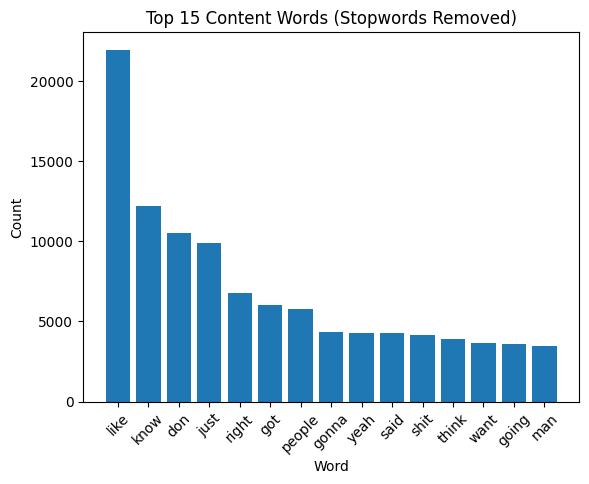

In [ ]:
words = [w for w, c in top15]
counts = [c for w, c in top15]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Content Words (Stopwords Removed)")
plt.ylabel("Count")
plt.xlabel("Word")
plt.show()

###### **Top 10 Most Common Words After Frequency Filtering**

In [ ]:
top10 = word_counts.most_common(10)

total_words = sum(word_counts.values())

top10_counts = [c for w, c in top10]
top10_words = [w for w, c in top10]

top10_percentages = [(c / total_words) * 100 for c in top10_counts]

rest_count = total_words - sum(top10_counts)
rest_percentage = (rest_count / total_words) * 100

print("Top 10 word percentages:")
for w, c, p in percentages:
    print(f"{w}: {c} ({p}%)")

Top 10 word percentages:
like: 21963 (3.290761056855265%)
know: 12205 (1.828700027269431%)
don: 10541 (1.579379515563054%)
just: 9913 (1.485284995520022%)
right: 6793 (1.017809036070565%)
got: 5998 (0.8986925656339243%)
people: 5746 (0.8609348919860836%)
gonna: 4345 (0.6510202063486831%)
yeah: 4257 (0.6378349869795958%)
said: 4253 (0.6372356588264555%)


In [ ]:
visual_rest_size = sum(top10_counts) * 0.2  # makes rest < quarter

sizes_visual = top10_counts + [visual_rest_size]

In [ ]:
labels = [
    f"{w} ({p}%)"
    for w, p in zip(top10_words, top10_percentages)
]

labels.append(f"Rest ({rest_percentage}%)")

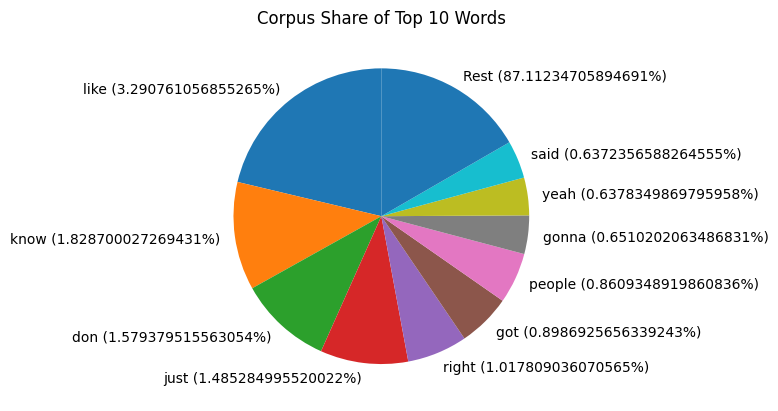

In [ ]:

plt.figure()

plt.pie(
    sizes_visual,
    labels=labels,
    startangle=90
)

plt.title("Corpus Share of Top 10 Words")

plt.show()

In [ ]:
word_counts = Counter(filtered_words)
total_words = sum(word_counts.values())
threshold = 0.003 * total_words
too_frequent = [
    w for w, c in word_counts.items()
    if c > threshold
]

print("Words above 0.5% threshold:")
print(too_frequent)

Words above 0.5% threshold:
['make', 'cause', 'thing', 'way', 'man', 'said', 'going', 'just', 'didn', 'got', 'time', 'people', 'like', 'yeah', 'right', 'look', 'think', 'good', 'don', 'love', 'want', 'gonna', 'really', 'little', 'did', 'come', 'know', 'let', 'tell', 'say', 'okay', 'guy', 'shit', 'fucking', 'fuck']


In [ ]:
filtered_words_freq = [
    w for w in filtered_words
    if w not in too_frequent
]

In [ ]:
final_counts = Counter(filtered_words_freq)
top15_final = final_counts.most_common(15)

print(top15_final)

[('god', 1913), ('day', 1844), ('goes', 1807), ('went', 1788), ('mean', 1782), ('hey', 1763), ('doing', 1761), ('guys', 1740), ('thank', 1670), ('life', 1666), ('lot', 1666), ('white', 1574), ('need', 1556), ('old', 1521), ('years', 1477)]


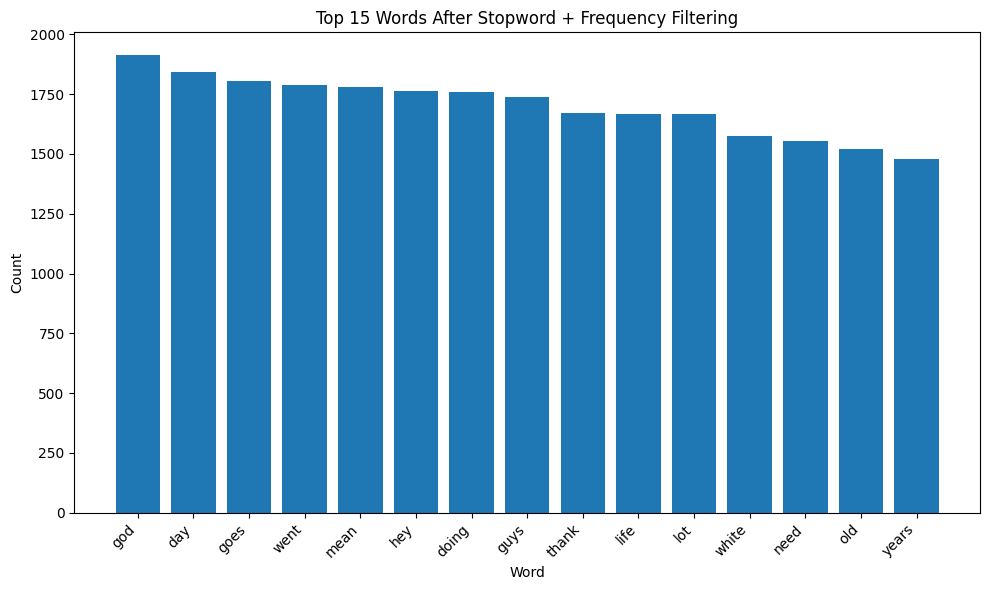

In [ ]:
words = [w for w, c in top15_final]
counts = [c for w, c in top15_final]

plt.figure(figsize=(10,6))

plt.bar(words, counts)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Word")
plt.ylabel("Count")

plt.title("Top 15 Words After Stopword + Frequency Filtering")

plt.tight_layout()
plt.show()

###### **Least Common Words**

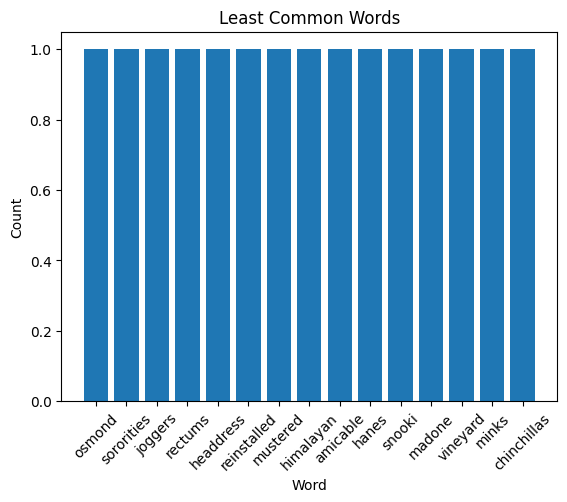

In [ ]:
least_common = [w for w, c in word_counts.items() if c == 1][:15]

least_counts = [word_counts[w] for w in least_common]

plt.figure()
plt.bar(least_common, least_counts)
plt.xticks(rotation=45)
plt.title("Least Common Words")
plt.ylabel("Count")
plt.xlabel("Word")
plt.show()

###### **Comedians Appearances in Corpus**

In [ ]:
comedian_counts = Counter()

for t in transcripts:
    title = t["title"]
    comedian = title.split(":")[0].strip()
    comedian_counts[comedian] += 1

In [ ]:
total_transcripts = len(transcripts)

comedian_fraction = {
    c: count / total_transcripts
    for c, count in comedian_counts.items()
}

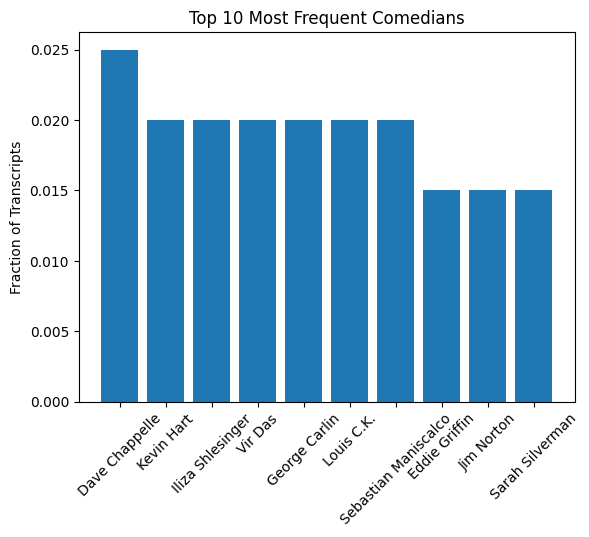

In [ ]:
top10 = sorted(comedian_fraction.items(), key=lambda x: x[1], reverse=True)[:10]

names = [x[0] for x in top10]
fractions = [x[1] for x in top10]

plt.figure()
plt.bar(names, fractions)
plt.xticks(rotation=45)
plt.ylabel("Fraction of Transcripts")
plt.title("Top 10 Most Frequent Comedians")
plt.show()

In [ ]:
values = list(comedian_fraction.values())

mean_fraction = np.mean(values)
median_fraction = np.median(values)
iqr_fraction = np.percentile(values, 75) - np.percentile(values, 25)

print("Mean fraction:", mean_fraction)
print("Median fraction:", median_fraction)
print("IQR:", iqr_fraction)

Mean fraction: 0.006666666666666666
Median fraction: 0.005
IQR: 0.0


In [ ]:
comedian_counts = Counter()

for t in transcripts:
    title = t["title"]
    comedian = title.split(":")[0].strip()
    comedian_counts[comedian] += 1

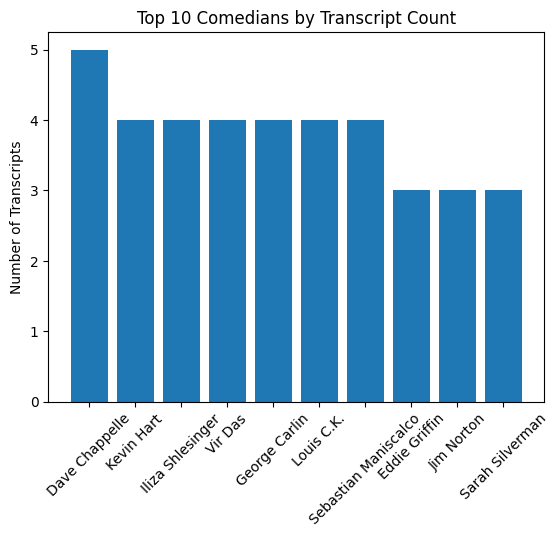

In [ ]:

top10 = comedian_counts.most_common(10)

names = [c for c, _ in top10]
counts = [count for _, count in top10]

plt.figure()
plt.bar(names, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Transcripts")
plt.title("Top 10 Comedians by Transcript Count")
plt.show()

In [ ]:
values = list(comedian_counts.values())

mean_count = np.mean(values)
median_count = np.median(values)

print("Mean transcripts per comedian:", mean_count)
print("Median transcripts per comedian:", median_count)

Mean transcripts per comedian: 1.3333333333333333
Median transcripts per comedian: 1.0


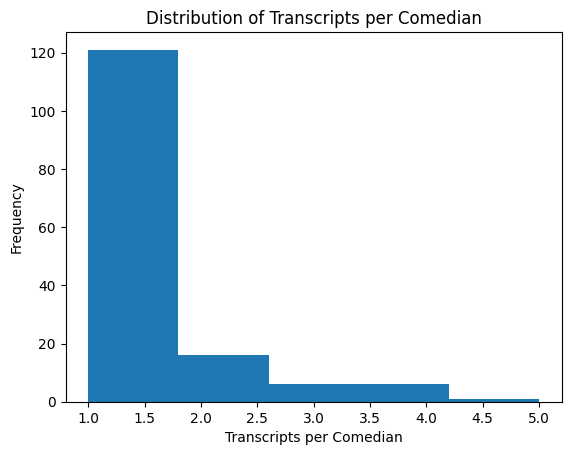

In [ ]:
plt.figure()
plt.hist(values, bins=5)
plt.xlabel("Transcripts per Comedian")
plt.ylabel("Frequency")
plt.title("Distribution of Transcripts per Comedian")
plt.show()